In [2]:
#  import all the required library

import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../data/heart_disease.csv')

In [4]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [5]:
df.shape

(10000, 21)

### Data Cleaning

## Handle missing values 

* handle missing values 
* Handle duplicates 
* data understanding

# Check the null values

In [6]:
df.isnull().sum()

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

In [7]:
df.drop('Heart Disease Status' , axis=1 , inplace = True)

In [8]:
df.select_dtypes(exclude= 'object').describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


we have seen in the EDA there no outliers we can fill null values with mean in numerical columns

In [9]:
# seprate numerical and categorical columns

num_col = [num for num in df.columns if df[num].dtype != 'str']
cat_col = [cat for cat in df.columns if df[cat].dtype == 'str']

In [10]:
num_col

['Age',
 'Blood Pressure',
 'Cholesterol Level',
 'BMI',
 'Sleep Hours',
 'Triglyceride Level',
 'Fasting Blood Sugar',
 'CRP Level',
 'Homocysteine Level']

In [11]:
cat_col

['Gender',
 'Exercise Habits',
 'Smoking',
 'Family Heart Disease',
 'Diabetes',
 'High Blood Pressure',
 'Low HDL Cholesterol',
 'High LDL Cholesterol',
 'Alcohol Consumption',
 'Stress Level',
 'Sugar Consumption']

In [12]:
for i in num_col :
    df[i] = df[i].fillna(df[i].mean())
    print(f"the mean value of column {i} is :  {df[i].mean()}")

the mean value of column Age is :  49.29625915153946
the mean value of column Blood Pressure is :  149.75773970544034
the mean value of column Cholesterol Level is :  225.42557673019058
the mean value of column BMI is :  29.07726892751104
the mean value of column Sleep Hours is :  6.991329446342599
the mean value of column Triglyceride Level is :  250.734409464608
the mean value of column Fasting Blood Sugar is :  120.14221286831028
the mean value of column CRP Level is :  7.472200593944747
the mean value of column Homocysteine Level is :  12.45627088214965


Because Alcohol consumption has High no of null valuse if we fill mode of the column in place of missing values there will be bias problem create heance we fill randomly

In [13]:
dist = df['Alcohol Consumption'].value_counts(normalize=True)

miss_data = df['Alcohol Consumption'].isnull()

df.loc[miss_data , 'Alcohol Consumption'] = np.random.choice(
    dist.index,
    size = miss_data.sum(),
    p = dist.values
)

In [14]:
cat_col = [cat for cat in cat_col if cat != 'Alcohol Consumption']

In [15]:
for i in cat_col:
    df[i] = df[i].fillna(df[i].mode()[0])
    
    print(f"mode value of the column {i} is : {df[i].mode()[0]}")
    print("..............................................")

mode value of the column Gender is : Male
..............................................
mode value of the column Exercise Habits is : High
..............................................
mode value of the column Smoking is : Yes
..............................................
mode value of the column Family Heart Disease is : No
..............................................
mode value of the column Diabetes is : No
..............................................
mode value of the column High Blood Pressure is : Yes
..............................................
mode value of the column Low HDL Cholesterol is : Yes
..............................................
mode value of the column High LDL Cholesterol is : No
..............................................
mode value of the column Stress Level is : Medium
..............................................
mode value of the column Sugar Consumption is : Low
..............................................


In [16]:
df.isnull().sum()

Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
dtype: int64

## Handle Duplicates

In [17]:
df.duplicated().sum()

np.int64(0)

## Feature Enginnering -

feature Engineering is the important part of ML where we add new feature with the help of existing feature 

In [18]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,Yes,No,High,Medium,7.633228,Medium,342.0,120.142213,12.969246,12.387250
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,Yes,No,Medium,High,8.744034,Medium,133.0,157.000000,9.355389,19.298875
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,Yes,Yes,Low,Low,4.440440,Low,393.0,92.000000,12.709873,11.230926
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,No,Yes,Low,High,5.249405,High,293.0,94.000000,12.509046,5.961958
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,No,No,Low,High,7.030971,High,263.0,154.000000,10.381259,8.153887


## categorical to numerical -

here we use map function because label encoder assign values randomly 

In [19]:
df['Gender'] = df['Gender'].map({'Male' : 0 , 'Female' : 1})
df['Exercise Habits'] = df['Exercise Habits'].map({'Low' : 0 , 'Medium' :1 , 'High' : 2})
df['Smoking'] = df['Smoking'].map({'Yes' : 1 , 'No' : 0})
df['Family Heart Disease'] = df['Family Heart Disease'].map({'Yes' : 1 , 'No' : 0})
df['Diabetes'] = df['Diabetes'].map({'Yes' : 1 , 'No' : 0})
df['High Blood Pressure'] = df['High Blood Pressure'].map({'Yes' : 1 , 'No' : 0})
df['Low HDL Cholesterol'] = df['Low HDL Cholesterol'].map({'Yes' : 1 , 'No' :0})
df['High LDL Cholesterol'] = df['High LDL Cholesterol'].map({'Yes' : 1 , 'No' :0})
df['Alcohol Consumption'] = df['Alcohol Consumption'].map({'Low' : 0 , 'Medium' :1 , 'High' : 2})
df['Stress Level'] = df['Stress Level'].map({'Low' : 0 , 'Medium' :1 , 'High' : 2})
df['Sugar Consumption'] = df['Sugar Consumption'].map({'Low' : 0 , 'Medium' :1 , 'High' : 2})


In [20]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
0,56.0,0,153.0,155.0,2,1,1,0,24.991591,1,1,0,2,1,7.633228,1,342.0,120.142213,12.969246,12.387250
1,69.0,1,146.0,286.0,2,0,1,1,25.221799,0,1,0,1,2,8.744034,1,133.0,157.000000,9.355389,19.298875
2,46.0,0,126.0,216.0,0,0,0,0,29.855447,0,1,1,0,0,4.440440,0,393.0,92.000000,12.709873,11.230926
3,32.0,1,122.0,293.0,2,1,1,0,24.130477,1,0,1,0,2,5.249405,2,293.0,94.000000,12.509046,5.961958
4,60.0,0,166.0,242.0,0,1,1,1,20.486289,1,0,0,0,2,7.030971,2,263.0,154.000000,10.381259,8.153887


## New feature 

In [21]:
df['chol_ratio'] = df['Cholesterol Level'] + (df['Low HDL Cholesterol'])

df['lifstyle_score'] = df['Exercise Habits'] + df['Sleep Hours'] - df['Smoking'] - df['Alcohol Consumption'] - df['Stress Level']

df['metabolic_risk'] = df['BMI'] + df['Fasting Blood Sugar'] + df['Triglyceride Level']

df['age_bmi_risk'] = df['Age'] * df['BMI']

df['inflammation '] = df['CRP Level'] + df['Homocysteine Level']

df1 = df.copy()

df1.drop(['Cholesterol Level' , 'Low HDL Cholesterol' , 'Exercise Habits' , 'Sleep Hours' , 'Smoking' , 'Alcohol Consumption' , 'Stress Level','BMI' , 'Fasting Blood Sugar' , 'Triglyceride Level' ,'CRP Level' , 'Homocysteine Level'] , axis=1 , inplace=True)

In [22]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,chol_ratio,lifstyle_score,metabolic_risk,age_bmi_risk,inflammation
0,56.0,0,153.0,155.0,2,1,1,0,24.991591,1,...,1,342.0,120.142213,12.969246,12.387250,156.0,5.633228,487.133804,1399.529101,25.356496
1,69.0,1,146.0,286.0,2,0,1,1,25.221799,0,...,1,133.0,157.000000,9.355389,19.298875,287.0,7.744034,315.221799,1740.304098,28.654265
2,46.0,0,126.0,216.0,0,0,0,0,29.855447,0,...,0,393.0,92.000000,12.709873,11.230926,217.0,4.440440,514.855447,1373.350569,23.940798
3,32.0,1,122.0,293.0,2,1,1,0,24.130477,1,...,2,293.0,94.000000,12.509046,5.961958,293.0,4.249405,411.130477,772.175260,18.471004
4,60.0,0,166.0,242.0,0,1,1,1,20.486289,1,...,2,263.0,154.000000,10.381259,8.153887,242.0,4.030971,437.486289,1229.177333,18.535146


## VIF - 



In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def variance(data):

    VIF = pd.DataFrame(data.columns , columns= ['Fetures'])
    VIF['vif'] = [variance_inflation_factor(data.values , i) for i in range(len(data.columns))]
    return VIF

In [24]:
variance(df1)

,Fetures,vif
0,Age,29.481709
1,Gender,1.982086
2,Blood Pressure,37.849936
3,Family Heart Disease,1.980381
4,Diabetes,1.975469
5,High Blood Pressure,2.008228
6,High LDL Cholesterol,1.965591
7,Sugar Consumption,2.436329
8,chol_ratio,22.877931
9,lifstyle_score,6.553129


In [25]:
df1.drop('Blood Pressure' , inplace=True , axis=1)

In [26]:
variance(df1)

,Fetures,vif
0,Age,28.990642
1,Gender,1.969944
2,Family Heart Disease,1.966504
3,Diabetes,1.958381
4,High Blood Pressure,1.990703
5,High LDL Cholesterol,1.954886
6,Sugar Consumption,2.419087
7,chol_ratio,18.387220
8,lifstyle_score,6.310847
9,metabolic_risk,15.331942


In [27]:
df1.drop('Age' , inplace=True , axis=1)

In [28]:
variance(df1)

,Fetures,vif
0,Gender,1.969308
1,Family Heart Disease,1.965716
2,Diabetes,1.955467
3,High Blood Pressure,1.990148
4,High LDL Cholesterol,1.954653
5,Sugar Consumption,2.418293
6,chol_ratio,18.040885
7,lifstyle_score,6.291916
8,metabolic_risk,15.300298
9,age_bmi_risk,5.890833


In [29]:
df1.drop('chol_ratio' , inplace=True , axis=1)

In [30]:
variance(df1)

,Fetures,vif
0,Gender,1.950708
1,Family Heart Disease,1.954027
2,Diabetes,1.939531
3,High Blood Pressure,1.976354
4,High LDL Cholesterol,1.942412
5,Sugar Consumption,2.388927
6,lifstyle_score,5.986701
7,metabolic_risk,12.357696
8,age_bmi_risk,5.637559
9,inflammation,9.066150


In [31]:
df1.drop('metabolic_risk' , inplace=True , axis=1)

In [32]:
variance(df1)

,Fetures,vif
0,Gender,1.930696
1,Family Heart Disease,1.929282
2,Diabetes,1.913248
3,High Blood Pressure,1.952296
4,High LDL Cholesterol,1.914126
5,Sugar Consumption,2.327146
6,lifstyle_score,5.460303
7,age_bmi_risk,5.100408
8,inflammation,7.424518


In [33]:
df1.drop('inflammation ' , inplace=True , axis=1)

In [34]:
variance(df1)

,Fetures,vif
0,Gender,1.890292
1,Family Heart Disease,1.879125
2,Diabetes,1.880026
3,High Blood Pressure,1.909493
4,High LDL Cholesterol,1.883087
5,Sugar Consumption,2.232624
6,lifstyle_score,4.715937
7,age_bmi_risk,4.461378


In [35]:
df1.columns

Index(['Gender', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure',
       'High LDL Cholesterol', 'Sugar Consumption', 'lifstyle_score',
       'age_bmi_risk'],
      dtype='str')

In [36]:
# import sys
# !{sys.executable} -m pip install statsmodels

In [37]:
df1.head()

,Gender,Family Heart Disease,Diabetes,High Blood Pressure,High LDL Cholesterol,Sugar Consumption,lifstyle_score,age_bmi_risk
0,0,1,0,1,0,1,5.633228,1399.529101
1,1,1,1,0,0,1,7.744034,1740.304098
2,0,0,0,0,1,0,4.440440,1373.350569
3,1,1,0,1,1,2,4.249405,772.175260
4,0,1,1,1,0,2,4.030971,1229.177333


## Create own data -

In medical data few feature will dominate so no group will create , clustring no a good idia for the medical dataset

In [38]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# x_scale = scaler.fit_transform(df1)
df1[['lifstyle_score' , 'age_bmi_risk']] = scaler.fit_transform(df1[['lifstyle_score' , 'age_bmi_risk']])

In [39]:
df1.head()

,Gender,Family Heart Disease,Diabetes,High Blood Pressure,High LDL Cholesterol,Sugar Consumption,lifstyle_score,age_bmi_risk
0,0,1,0,1,0,1,0.511301,0.374804
1,1,1,1,0,0,1,0.674302,0.493775
2,0,0,0,0,1,0,0.419191,0.365665
3,1,1,0,1,1,2,0.404439,0.155783
4,0,1,1,1,0,2,0.387571,0.315331


Based on domain knowledge create new feature and according to feature importance also apply it weights 

In [40]:
risk_score2 = (
    df1['High Blood Pressure'] *2.5 +
    df1['High LDL Cholesterol'] *2.5 +
    df1['Family Heart Disease'] *2.5 +
    df1['age_bmi_risk'] * 2 +
    df1['lifstyle_score'] * 1.5 +
    df1['Sugar Consumption'] *1.5 +
    df1['Gender'] *0.3
)

In [41]:
dfff = df1.copy()
dfff['health risk'] = pd.cut(
    risk_score2 , 
    bins = [risk_score2.min()-1 , 4 , 7 , risk_score2.max()+1] ,
    # q = 3,
    labels = ['Low' , 'Medium' ,'High']
)

In [42]:
dfff.head(10)

,Gender,Family Heart Disease,Diabetes,High Blood Pressure,High LDL Cholesterol,Sugar Consumption,lifstyle_score,age_bmi_risk,health risk
0,0,1,0,1,0,1,0.511301,0.374804,High
1,1,1,1,0,0,1,0.674302,0.493775,Medium
2,0,0,0,0,1,0,0.419191,0.365665,Low
3,1,1,0,1,1,2,0.404439,0.155783,High
4,0,1,1,1,0,2,0.387571,0.315331,High
5,0,0,0,0,0,0,0.346944,0.131848,Low
6,1,1,1,0,0,1,0.712673,0.377518,Medium
7,1,1,1,0,0,2,0.527346,0.347037,High
8,1,1,1,1,1,2,0.457877,0.560565,High
9,0,1,0,0,1,2,0.230940,0.675442,High


In [43]:
risk_score2.describe()

count    10000.000000
mean         6.901280
std          2.547376
min          0.256456
25%          5.064599
50%          6.882955
75%          8.762330
max         13.931999
dtype: float64

In [44]:
dfff['health risk'].value_counts()

health risk
High      4762
Medium    3884
Low       1354
Name: count, dtype: int64

we need to balanced the dataset first 

In [45]:
import os

os.makedirs("data2" , exist_ok=True)
dfff.to_csv('data2/doctoc_data.csv' , index=False)

### Patient model Data

In [46]:
new_df = df.copy()

In [47]:
new_df.isnull().sum()

Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
chol_ratio              0
lifstyle_score          0
metabolic_risk          0
age_bmi_risk            0
inflammation            0
dtype: int64

In [48]:
df.columns

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'chol_ratio', 'lifstyle_score',
       'metabolic_risk', 'age_bmi_risk', 'inflammation '],
      dtype='str')

In [49]:
# drop all created features

new_df.drop(['chol_ratio', 'lifstyle_score','metabolic_risk', 'age_bmi_risk', 'inflammation '] , axis=1 , inplace=True)

In [50]:
new_df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
0,56.0,0,153.0,155.0,2,1,1,0,24.991591,1,1,0,2,1,7.633228,1,342.0,120.142213,12.969246,12.387250
1,69.0,1,146.0,286.0,2,0,1,1,25.221799,0,1,0,1,2,8.744034,1,133.0,157.000000,9.355389,19.298875
2,46.0,0,126.0,216.0,0,0,0,0,29.855447,0,1,1,0,0,4.440440,0,393.0,92.000000,12.709873,11.230926
3,32.0,1,122.0,293.0,2,1,1,0,24.130477,1,0,1,0,2,5.249405,2,293.0,94.000000,12.509046,5.961958
4,60.0,0,166.0,242.0,0,1,1,1,20.486289,1,0,0,0,2,7.030971,2,263.0,154.000000,10.381259,8.153887


In [51]:
variance(new_df)

,Fetures,vif
0,Age,8.036225
1,Gender,1.987445
2,Blood Pressure,46.806470
3,Cholesterol Level,24.285113
4,Exercise Habits,2.522980
5,Smoking,2.053746
6,Family Heart Disease,1.983703
7,Diabetes,1.978858
8,BMI,20.240098
9,High Blood Pressure,2.016586


In [52]:
new_df.drop('Blood Pressure' , axis=1 , inplace=True)

In [53]:
variance(new_df)

,Fetures,vif
0,Age,7.898057
1,Gender,1.982324
2,Cholesterol Level,22.421451
3,Exercise Habits,2.510351
4,Smoking,2.048306
5,Family Heart Disease,1.976754
6,Diabetes,1.969685
7,BMI,18.942642
8,High Blood Pressure,2.009804
9,Low HDL Cholesterol,1.995891


In [54]:
new_df.drop('Cholesterol Level' , axis=1 , inplace=True)

In [55]:
variance(new_df)

,Fetures,vif
0,Age,7.754998
1,Gender,1.976839
2,Exercise Habits,2.502782
3,Smoking,2.042572
4,Family Heart Disease,1.974142
5,Diabetes,1.965729
6,BMI,17.892597
7,High Blood Pressure,2.007779
8,Low HDL Cholesterol,1.992512
9,High LDL Cholesterol,1.963931


In [56]:
new_df.drop('Fasting Blood Sugar' , axis=1 , inplace=True)

In [57]:
variance(new_df)

,Fetures,vif
0,Age,7.570419
1,Gender,1.970832
2,Exercise Habits,2.493140
3,Smoking,2.033853
4,Family Heart Disease,1.969427
5,Diabetes,1.959771
6,BMI,16.357662
7,High Blood Pressure,2.000747
8,Low HDL Cholesterol,1.985603
9,High LDL Cholesterol,1.956618


In [58]:
new_df.drop('BMI' , axis=1 , inplace=True)

In [59]:
variance(new_df)

,Fetures,vif
0,Age,7.232727
1,Gender,1.956588
2,Exercise Habits,2.473250
3,Smoking,2.026364
4,Family Heart Disease,1.962289
5,Diabetes,1.952685
6,High Blood Pressure,1.988960
7,Low HDL Cholesterol,1.975652
8,High LDL Cholesterol,1.944062
9,Alcohol Consumption,2.445788


In [60]:
new_df.drop('Sleep Hours' , axis=1 , inplace=True)

In [61]:
variance(new_df)

,Fetures,vif
0,Age,6.779970
1,Gender,1.942528
2,Exercise Habits,2.451209
3,Smoking,2.010944
4,Family Heart Disease,1.949086
5,Diabetes,1.933408
6,High Blood Pressure,1.970297
7,Low HDL Cholesterol,1.966224
8,High LDL Cholesterol,1.928050
9,Alcohol Consumption,2.421553


In [62]:
new_df.drop('Triglyceride Level' , axis=1 , inplace=True)

In [63]:
variance(new_df)

,Fetures,vif
0,Age,6.397529
1,Gender,1.934385
2,Exercise Habits,2.431306
3,Smoking,1.995076
4,Family Heart Disease,1.937885
5,Diabetes,1.921605
6,High Blood Pressure,1.961151
7,Low HDL Cholesterol,1.947436
8,High LDL Cholesterol,1.913299
9,Alcohol Consumption,2.393570


In [64]:
new_df.drop('Homocysteine Level' , axis=1 , inplace=True)

In [65]:
variance(new_df)

,Fetures,vif
0,Age,5.738195
1,Gender,1.916281
2,Exercise Habits,2.387865
3,Smoking,1.976686
4,Family Heart Disease,1.914136
5,Diabetes,1.904362
6,High Blood Pressure,1.942677
7,Low HDL Cholesterol,1.923260
8,High LDL Cholesterol,1.895733
9,Alcohol Consumption,2.353032


In [66]:
new_df.head()

,Age,Gender,Exercise Habits,Smoking,Family Heart Disease,Diabetes,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sugar Consumption,CRP Level
0,56.0,0,2,1,1,0,1,1,0,2,1,1,12.969246
1,69.0,1,2,0,1,1,0,1,0,1,2,1,9.355389
2,46.0,0,0,0,0,0,0,1,1,0,0,0,12.709873
3,32.0,1,2,1,1,0,1,0,1,0,2,2,12.509046
4,60.0,0,0,1,1,1,1,0,0,0,2,2,10.381259


# Drop unwanted columns where user will strugal

In [67]:
new_df.drop(['CRP Level' , 'Low HDL Cholesterol' ,'High LDL Cholesterol'] , axis=1 , inplace=True)

In [68]:
new_df.head()

,Age,Gender,Exercise Habits,Smoking,Family Heart Disease,Diabetes,High Blood Pressure,Alcohol Consumption,Stress Level,Sugar Consumption
0,56.0,0,2,1,1,0,1,2,1,1
1,69.0,1,2,0,1,1,0,1,2,1
2,46.0,0,0,0,0,0,0,0,0,0
3,32.0,1,2,1,1,0,1,0,2,2
4,60.0,0,0,1,1,1,1,0,2,2


## Scaling

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(new_df)

## Kmeans clustring

In [70]:
X = pd.DataFrame(X , columns=new_df.columns)

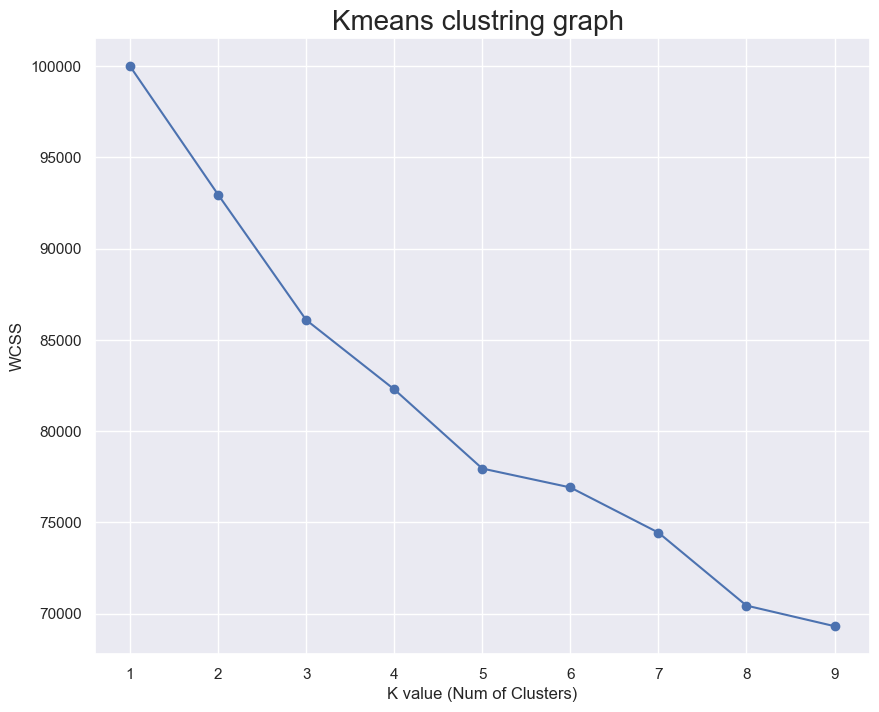

In [71]:
from sklearn.cluster import KMeans

wcss = {}
sns.set()
plt.figure(figsize=(10 , 8))
for i in range(1 , len(X.columns)):
    km = KMeans(n_clusters=i)
    km.fit(X)
    wcss[i] = km.inertia_

plt.plot(range(1 , len(X.columns)) , wcss.values() , marker="o")
plt.title('Kmeans clustring graph ', fontsize =20)
plt.xlabel('K value (Num of Clusters)')
plt.ylabel('WCSS')
plt.show()

In [76]:
from sklearn.metrics import silhouette_score
km = KMeans(n_clusters=8)
km.fit(X)
x_labels = km.predict(X)
silhouette_score(X , x_labels)

0.10459713304727207

## DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN

db = DBSCAN()
x_labels = db.fit_predict(X)
silhouette_score(X , x_labels)

-0.43276574742688706

here no cluster creating hence create own target group using domaine knowlenge

In [83]:
risk_score = (
    new_df['Smoking']*2 +
    new_df['Alcohol Consumption']*1.5 +
    new_df['Stress Level']*1.5+
    new_df['Sugar Consumption']*1.5 +
    new_df['Exercise Habits']*(-2) + # good exercise reduce risk
    new_df['Family Heart Disease']*2 +
    new_df['Diabetes']*2 +
    new_df['High Blood Pressure']*2 +
    (new_df['Age'] >50)*2
)

In [94]:
risk_score.describe()

count    10000.000000
mean         7.434850
std          3.490236
min         -4.000000
25%          5.000000
50%          7.500000
75%         10.000000
max         19.000000
dtype: float64

In [ ]:
new_df['heakth risk'] = pd.cut(
    risk_score ,
    bins = [-5 , 5 , 9 , 20],
    labels=['Low' , 'Medium' , 'High']
)

In [97]:
new_df.head(10)

,Age,Gender,Exercise Habits,Smoking,Family Heart Disease,Diabetes,High Blood Pressure,Alcohol Consumption,Stress Level,Sugar Consumption,heakth risk
0,56.0,0,2,1,1,0,1,2,1,1,High
1,69.0,1,2,0,1,1,0,1,2,1,Medium
2,46.0,0,0,0,0,0,0,0,0,0,Low
3,32.0,1,2,1,1,0,1,0,2,2,Medium
4,60.0,0,0,1,1,1,1,0,2,2,High
5,25.0,0,0,1,0,0,0,0,1,0,Low
6,78.0,1,2,1,1,1,0,1,1,1,Medium
7,38.0,1,0,1,1,1,0,0,1,2,High
8,56.0,1,0,0,1,1,1,2,0,2,High
9,75.0,0,0,1,1,0,0,0,1,2,High


In [98]:
new_df['heakth risk'].unique()

['High', 'Medium', 'Low']
Categories (3, str): ['Low' < 'Medium' < 'High']

In [99]:
new_df['heakth risk'].value_counts()

heakth risk
Medium    4212
High      3016
Low       2772
Name: count, dtype: int64

In [101]:
os.makedirs('data2' , exist_ok=True)
new_df.to_csv("data2/patient_data.csv" , index=False)